# Chicken tournament analysis

Round-robin tournament of 5 agents (RB, WSLS, 0-TOM, 1-TOM, 2-TOM) on the Chicken game. Mirrors the basic experiment in `run.py` but with `save_history=True` so we can plot per-round dynamics and the 2-TOM agent's internal beliefs about its opponents.

Plotting helpers from tomsup tutorial `Getting_started.ipynb` section 4.

In [2]:
import os
import warnings

# tomsup's package dir shares a name with the cloned-repo root; chdir away
# so the installed package is found rather than the empty namespace package.
os.chdir("/tmp")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import tomsup as ts

OUT_DIR = "/Users/yoav.levy/chicken"
N_ROUNDS = 50
N_SIM = 50
CRASH = -10.0


def chicken_matrix(crash: float = CRASH) -> ts.PayoffMatrix:
    m = np.array(
        [
            [(0.0, -1.0), (1.0, crash)],
            [(0.0, 1.0), (-1.0, crash)],
        ],
        dtype=float,
    )
    return ts.PayoffMatrix(name="custom", predefined=m)


def save(path: str) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    print(f"saved {path}")

## Run the tournament

tomsup's k-ToM update can occasionally NaN on rare random initializations. The cell below sweeps over a list of seeds and uses the first one that runs cleanly.

In [3]:
matrix = chicken_matrix()
agent_names = ["RB", "WSLS", "0-TOM", "1-TOM", "2-TOM"]
start_params = [{"bias": 0.5}, {}, {}, {}, {}]

print(f"Running round-robin tournament: N_rounds={N_ROUNDS}, N_sim={N_SIM}\u2026")
for seed in [42, 7, 123, 2024, 99, 0]:
    np.random.seed(seed)
    try:
        group = ts.create_agents(agent_names, start_params)
        group.set_env("round_robin")
        group.compete(
            p_matrix=matrix, n_rounds=N_ROUNDS, n_sim=N_SIM,
            save_history=True, verbose=False,
        )
        print(f"  succeeded with seed={seed}")
        break
    except ValueError as e:
        print(f"  seed={seed} failed ({e}); retrying\u2026")
else:
    raise RuntimeError("All seeds NaN'd; consider reducing n_sim or n_rounds")

Running round-robin tournament: N_rounds=50, N_sim=50…
  succeeded with seed=42


## Choice and cumulative score over rounds

Focal agent is `agent=1` (the named `a1`); opponent is `a0`. Title format: *"X playing against Y"*.

In [ ]:
key_pairs = [
    ("0-TOM", "1-TOM"),
    ("0-TOM", "2-TOM"),
    ("1-TOM", "2-TOM"),
    ("RB",    "2-TOM"),
    ("WSLS",  "2-TOM"),
]
for a0, a1 in key_pairs:
    plt.figure(figsize=(7, 4))
    group.plot_choice(agent0=a0, agent1=a1, agent=1,
                      plot_individual_sim=False, show=False)
    plt.title(f"{a1} playing against {a0}")
    plt.xlabel("Round")
    plt.ylabel("Action (0 = Swerve, 1 = Straight)")
    save(os.path.join(OUT_DIR, f"meas_choice_{a1}_vs_{a0}.png"))
    plt.show()

    plt.figure(figsize=(7, 4))
    group.plot_score(agent0=a0, agent1=a1, agent=1, show=False)
    plt.title(f"{a1} playing against {a0}")
    plt.xlabel("Round")
    plt.ylabel("Cumulative payoff")
    save(os.path.join(OUT_DIR, f"meas_score_{a1}_vs_{a0}.png"))
    plt.show()

## 2-TOM's estimated opponent sophistication

For each opponent, 2-TOM maintains a posterior over the opponent's sophistication level *k* ∈ {0, 1}. Each plot overlays `P(opp = 0-TOM)` and `P(opp = 1-TOM)` per round.

<Figure size 640x480 with 0 Axes>

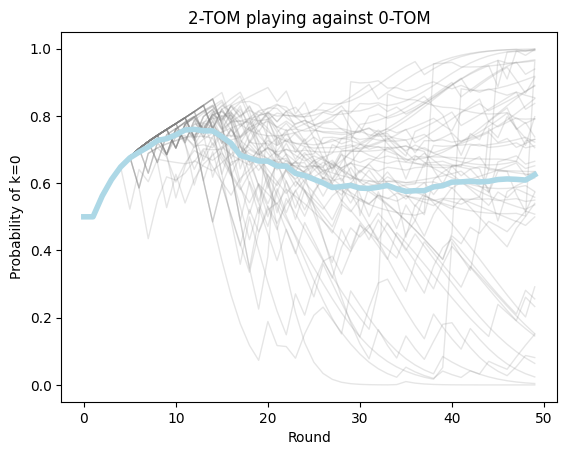

<Figure size 640x480 with 0 Axes>

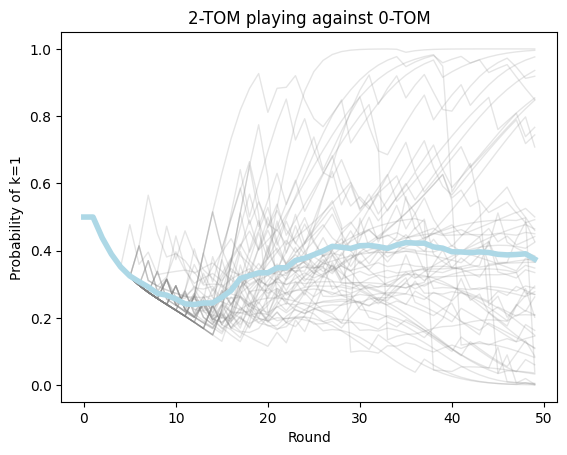

<Figure size 640x480 with 0 Axes>

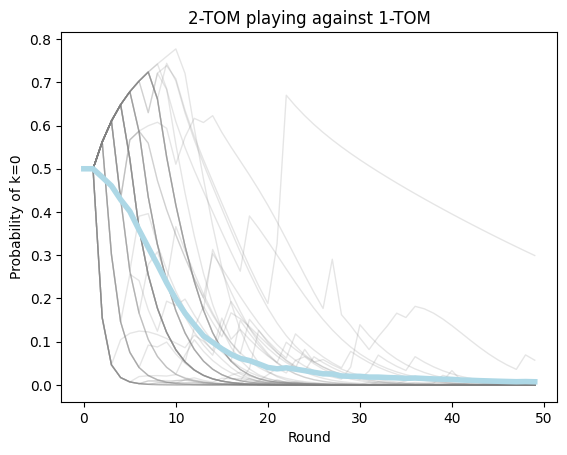

<Figure size 640x480 with 0 Axes>

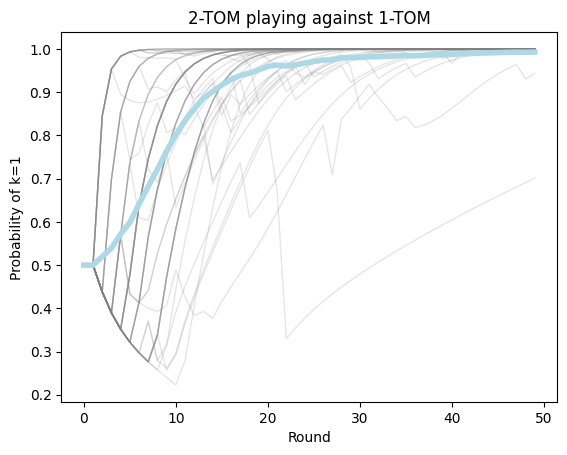

In [5]:
for opp in ["0-TOM", "1-TOM"]:
    group.plot_p_k(agent0=opp, agent1="2-TOM", agent=1, level=0)
    group.plot_p_k(agent0=opp, agent1="2-TOM", agent=1, level=1)
    # save(os.path.join(OUT_DIR, f"meas_pk_2TOM_vs_{opp}.png"))
    plt.show()